<a href="https://www.kaggle.com/code/lalit7881/pulse-2026-music-virality-eda?scriptVersionId=314018123" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/artheon/pulse-2026-music-evolution-and-viral-analytics/Music_Evolution_2026_Pulse.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/artheon/pulse-2026-music-evolution-and-viral-analytics/Music_Evolution_2026_Pulse.csv")

In [3]:
df.head()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute,Vocal_Balance,Energy_Density,Vibe_Score,Viral_Potential_Index
0,0.975000,-12.550260,0.023500,0.358178,0.003424,0.225496,0.651890,264606.551066,0.765595,117.109723,0.003150,0.287894,0.552095,0.462136
1,0.513300,-1.616862,0.024072,0.513633,0.000001,0.176413,0.283309,206351.879142,0.613481,148.836001,-0.150584,0.094700,0.275487,0.356314
2,0.636704,-7.662865,0.024492,0.132557,0.166124,0.152315,0.628489,290156.180452,0.814531,128.698751,0.021346,0.034244,0.357336,0.416557
3,0.767151,-9.441020,0.066747,0.332356,0.196040,0.199684,0.501320,158079.704705,0.242119,72.913466,-0.117992,0.023652,0.528508,0.305117
4,0.625258,-1.605062,0.101830,0.160555,0.086590,0.027419,0.419884,257188.627463,0.575931,125.283749,-0.210277,0.333675,0.626095,0.483792


In [4]:
df.tail()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute,Vocal_Balance,Energy_Density,Vibe_Score,Viral_Potential_Index
49995,0.693355,-11.760228,0.024483,0.766976,0.100154,0.281158,0.951758,154352.779438,0.690029,113.189619,-0.103400,0.051054,0.166294,0.330733
49996,0.477123,-8.854438,0.137428,0.421097,0.348836,0.402356,0.715310,253461.325000,0.616987,136.269387,0.072555,0.155423,0.317179,0.348724
49997,0.710308,-13.683687,0.126748,0.510734,0.236090,0.276516,0.555849,266000.731716,0.722714,70.813030,0.055875,0.128640,0.572093,0.469945
49998,0.475986,-5.532633,0.083998,0.402395,0.032520,0.303360,0.830636,227694.610671,0.018813,130.217330,-0.047031,0.022050,0.500290,0.195795
49999,0.389205,-6.088349,0.024750,0.000593,0.000216,0.178676,0.765229,210650.634244,0.033667,118.544970,0.023492,0.155353,0.585941,0.223911


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   RhythmScore                50000 non-null  float64
 1   AudioLoudness              50000 non-null  float64
 2   VocalContent               50000 non-null  float64
 3   AcousticQuality            50000 non-null  float64
 4   InstrumentalScore          50000 non-null  float64
 5   LivePerformanceLikelihood  50000 non-null  float64
 6   MoodScore                  50000 non-null  float64
 7   TrackDurationMs            50000 non-null  float64
 8   Energy                     50000 non-null  float64
 9   BeatsPerMinute             50000 non-null  float64
 10  Vocal_Balance              50000 non-null  float64
 11  Energy_Density             50000 non-null  float64
 12  Vibe_Score                 50000 non-null  float64
 13  Viral_Potential_Index      50000 non-null  flo

In [6]:
df.describe()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute,Vocal_Balance,Energy_Density,Vibe_Score,Viral_Potential_Index
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,0.613879,-7.751244,0.083409,0.291456,0.112996,0.201979,0.551673,247782.846384,0.485005,118.236413,-0.055831,0.138020,0.363734,0.335264
std,0.153493,4.337001,0.044689,0.202844,0.116464,0.114148,0.204045,64961.695445,0.283955,26.615146,0.146399,0.083264,0.155222,0.116535
min,0.267311,-26.077279,0.023500,0.000005,0.000001,0.024300,0.025600,63973.000000,0.000200,46.836780,-0.554368,0.000050,0.006445,0.006155
25%,0.484574,-10.021115,0.038256,0.148165,0.004429,0.095422,0.458726,209141.367164,0.255325,98.135077,-0.177990,0.078900,0.253441,0.246917
50%,0.622407,-8.547457,0.088915,0.320630,0.078376,0.213215,0.547093,254585.044495,0.495518,115.158013,-0.031609,0.142203,0.348192,0.337685
75%,0.719481,-4.323856,0.108415,0.384426,0.166836,0.286553,0.694412,294652.827301,0.744601,139.656025,0.063579,0.179972,0.486449,0.423854
max,0.975000,-1.357000,0.248959,0.995000,0.577967,0.554708,0.978000,397292.154200,1.000000,201.415529,0.246858,0.594708,0.953550,0.727396


In [7]:
df.columns

Index(['RhythmScore', 'AudioLoudness', 'VocalContent', 'AcousticQuality',
       'InstrumentalScore', 'LivePerformanceLikelihood', 'MoodScore',
       'TrackDurationMs', 'Energy', 'BeatsPerMinute', 'Vocal_Balance',
       'Energy_Density', 'Vibe_Score', 'Viral_Potential_Index'],
      dtype='object')

In [8]:
df.dtypes

RhythmScore                  float64
AudioLoudness                float64
VocalContent                 float64
AcousticQuality              float64
InstrumentalScore            float64
LivePerformanceLikelihood    float64
MoodScore                    float64
TrackDurationMs              float64
Energy                       float64
BeatsPerMinute               float64
Vocal_Balance                float64
Energy_Density               float64
Vibe_Score                   float64
Viral_Potential_Index        float64
dtype: object

In [9]:
df.shape

(50000, 14)

In [10]:
df.nunique()

RhythmScore                  49509
AudioLoudness                46176
VocalContent                 45773
AcousticQuality              47409
InstrumentalScore            42728
LivePerformanceLikelihood    47700
MoodScore                    48501
TrackDurationMs              49855
Energy                       49539
BeatsPerMinute               49978
Vocal_Balance                49995
Energy_Density               49914
Vibe_Score                   49797
Viral_Potential_Index        50000
dtype: int64

In [11]:
df.isnull().sum()

RhythmScore                  0
AudioLoudness                0
VocalContent                 0
AcousticQuality              0
InstrumentalScore            0
LivePerformanceLikelihood    0
MoodScore                    0
TrackDurationMs              0
Energy                       0
BeatsPerMinute               0
Vocal_Balance                0
Energy_Density               0
Vibe_Score                   0
Viral_Potential_Index        0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

## EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   RhythmScore                50000 non-null  float64
 1   AudioLoudness              50000 non-null  float64
 2   VocalContent               50000 non-null  float64
 3   AcousticQuality            50000 non-null  float64
 4   InstrumentalScore          50000 non-null  float64
 5   LivePerformanceLikelihood  50000 non-null  float64
 6   MoodScore                  50000 non-null  float64
 7   TrackDurationMs            50000 non-null  float64
 8   Energy                     50000 non-null  float64
 9   BeatsPerMinute             50000 non-null  float64
 10  Vocal_Balance              50000 non-null  float64
 11  Energy_Density             50000 non-null  float64
 12  Vibe_Score                 50000 non-null  float64
 13  Viral_Potential_Index      50000 non-null  flo

<Figure size 1600x1000 with 0 Axes>

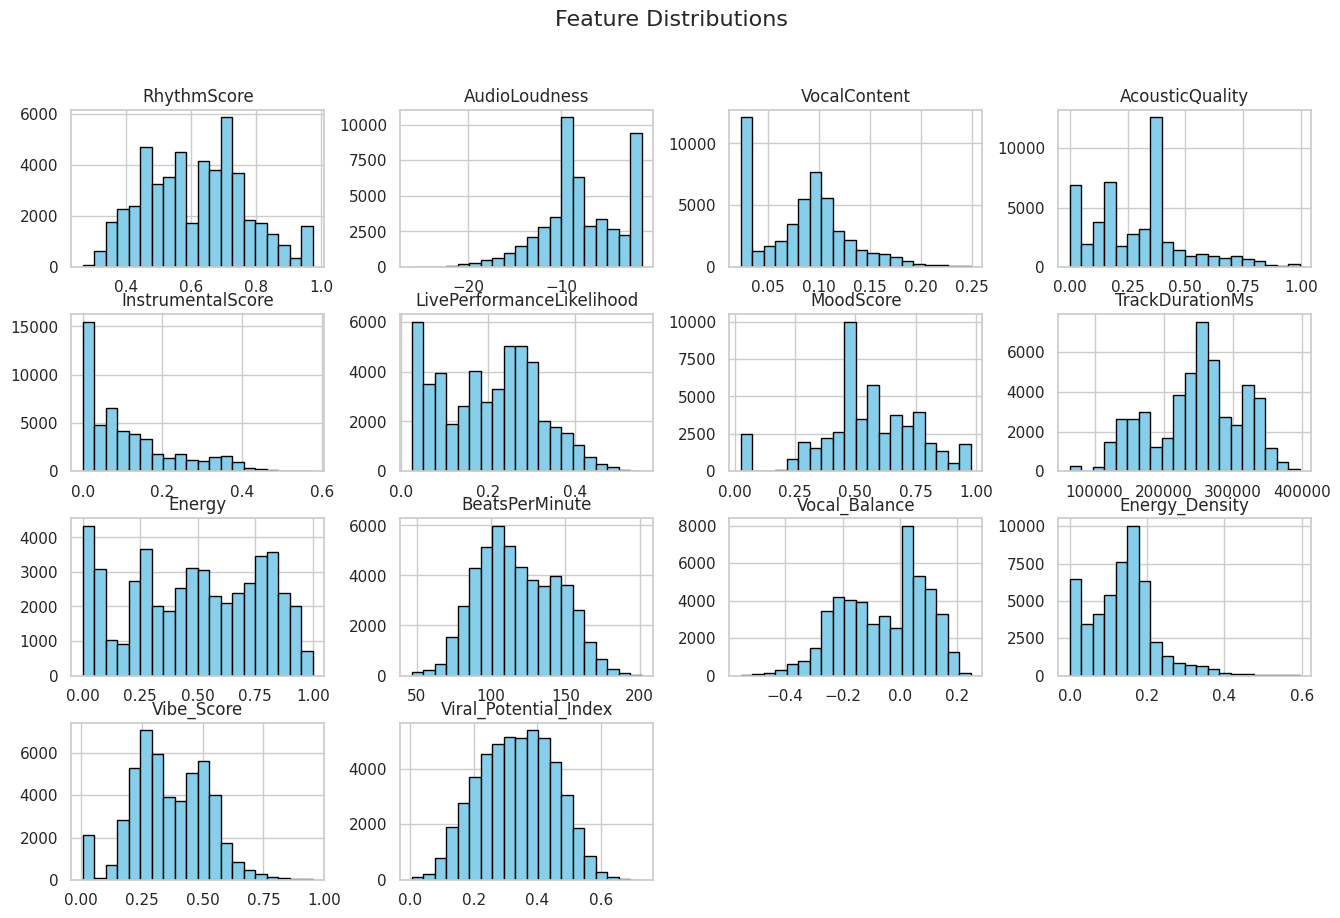

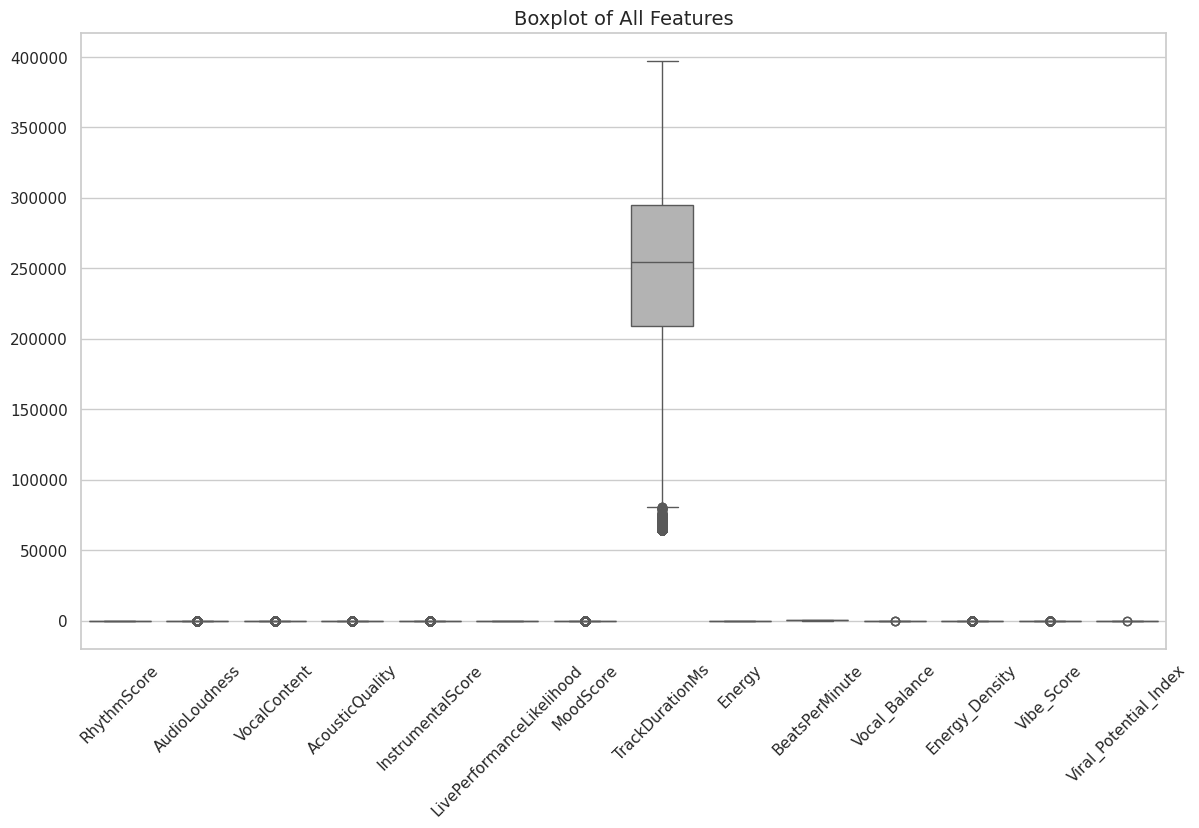

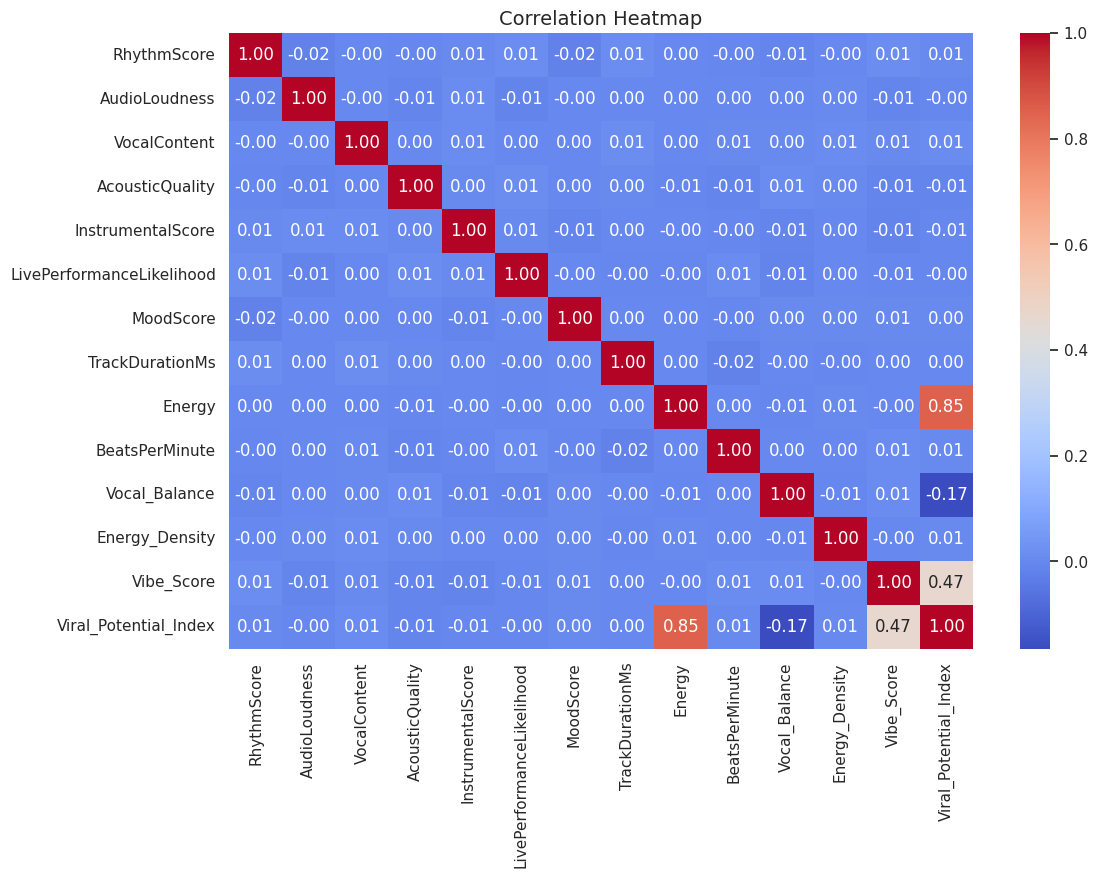

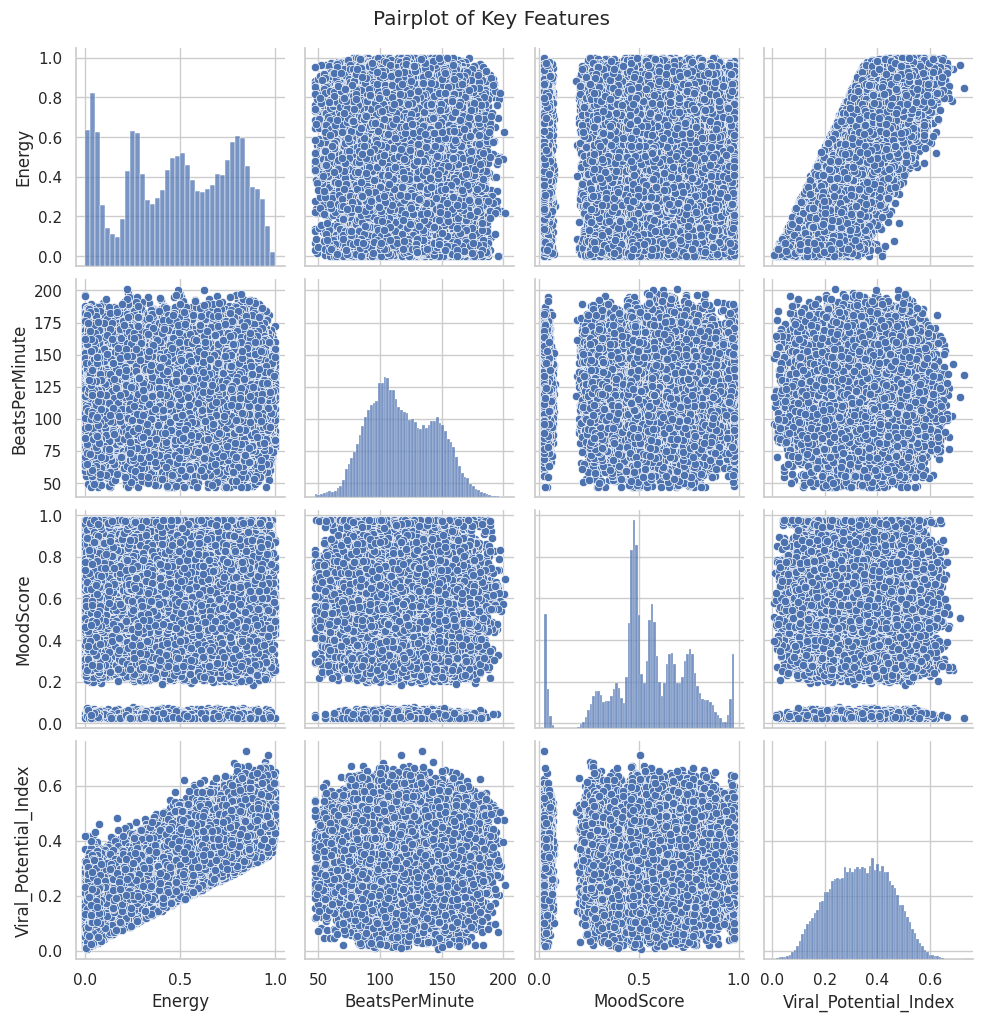

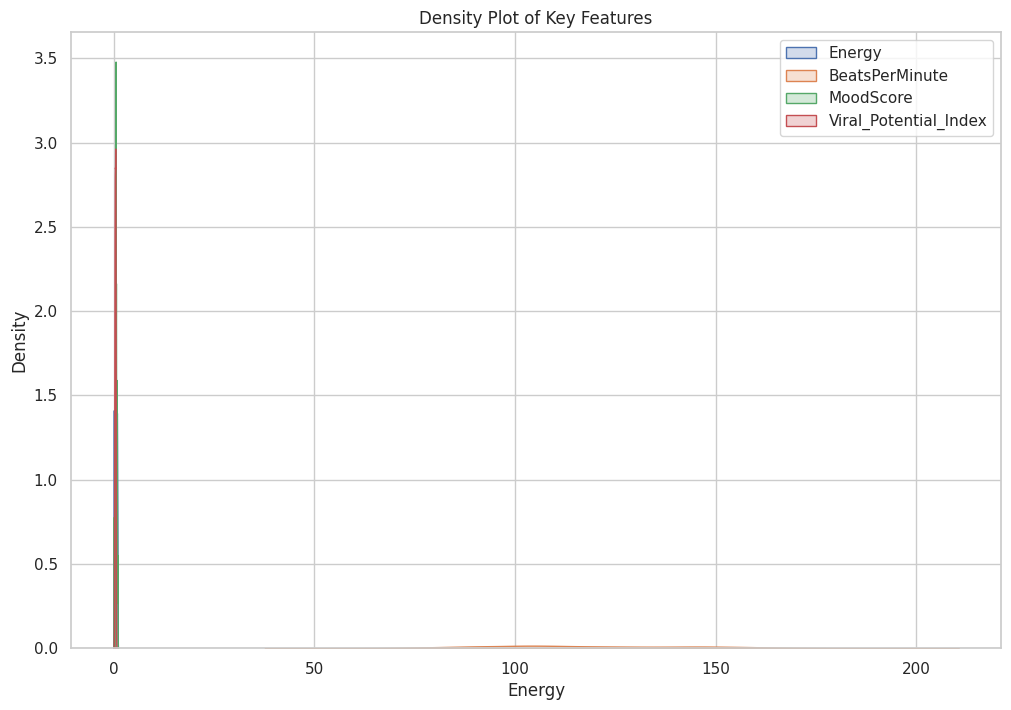

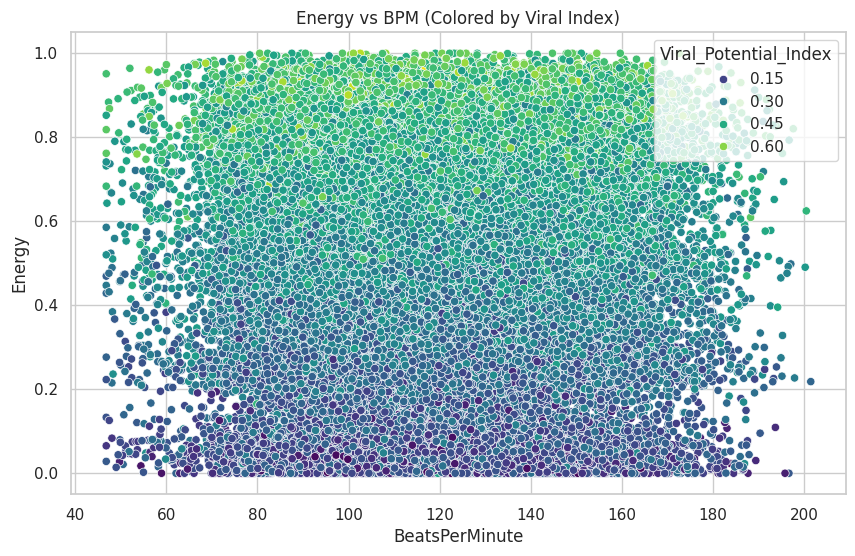

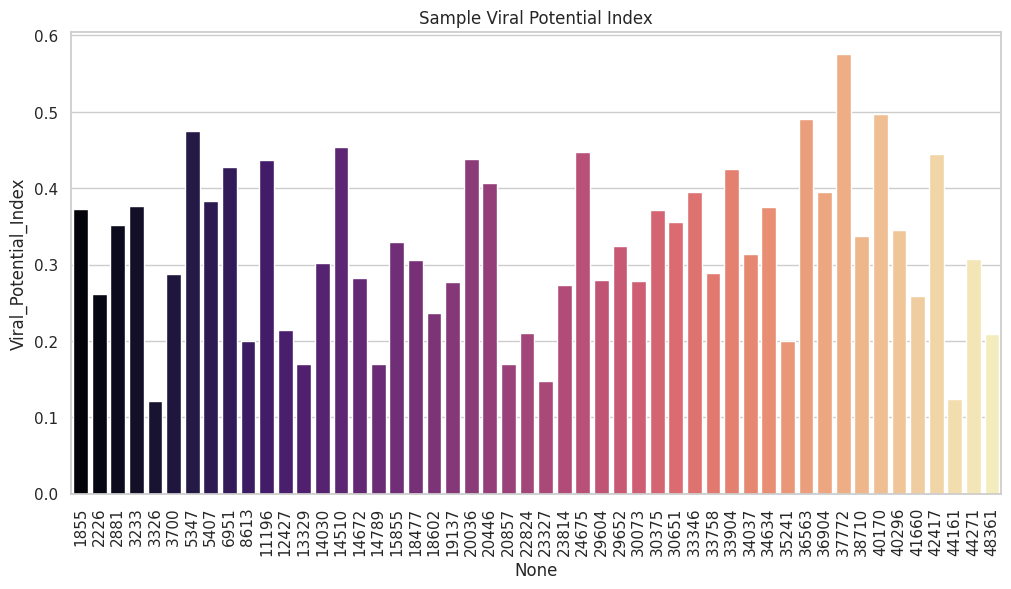

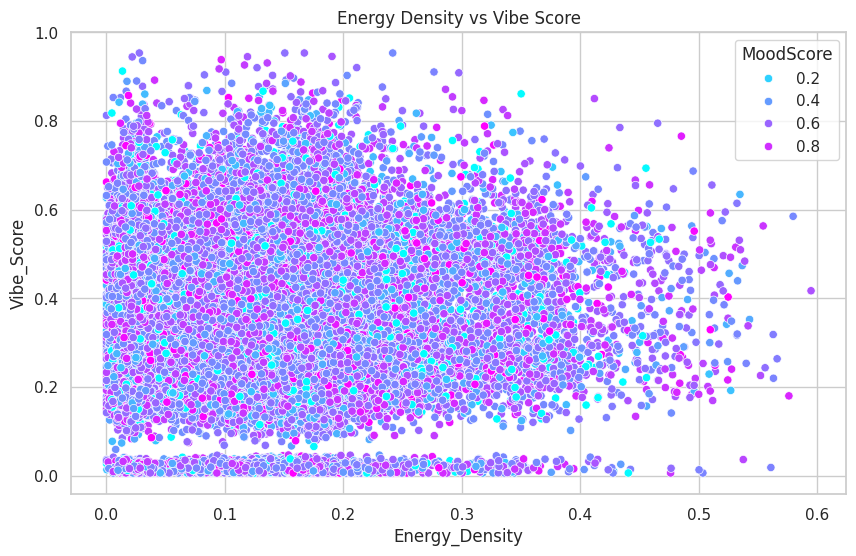

In [13]:
# Set style
sns.set(style="whitegrid")

# -------------------------------
# 1. Basic Info
# -------------------------------
print(df.info())
print(df.describe())

# -------------------------------
# 2. Histogram (All Features)
# -------------------------------
plt.figure(figsize=(16, 10))
df.hist(bins=20, figsize=(16,10), color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

# -------------------------------
# 3. Boxplot (Outlier Detection)
# -------------------------------
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, palette="Set2")
plt.xticks(rotation=45)
plt.title("Boxplot of All Features", fontsize=14)
plt.show()

# -------------------------------
# 4. Correlation Heatmap
# -------------------------------
plt.figure(figsize=(12, 8))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap", fontsize=14)
plt.show()

# -------------------------------
# 5. Pairplot (Important Features)
# -------------------------------
sample_cols = [
    'Energy', 'BeatsPerMinute', 'MoodScore',
    'Viral_Potential_Index'
]

sns.pairplot(df[sample_cols], palette="husl")
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()

# -------------------------------
# 6. KDE Plots (Density)
# -------------------------------
plt.figure(figsize=(12, 8))

for col in sample_cols:
    sns.kdeplot(df[col], label=col, fill=True)

plt.title("Density Plot of Key Features")
plt.legend()
plt.show()

# -------------------------------
# 7. Scatter Plots
# -------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df['BeatsPerMinute'],
    y=df['Energy'],
    hue=df['Viral_Potential_Index'],
    palette="viridis"
)
plt.title("Energy vs BPM (Colored by Viral Index)")
plt.show()

# -------------------------------
# 8. Bar Plot (Sampled Data)
# -------------------------------
sample_df = df.sample(50)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=sample_df.index,
    y=sample_df['Viral_Potential_Index'],
    palette="magma"
)
plt.xticks(rotation=90)
plt.title("Sample Viral Potential Index")
plt.show()

# -------------------------------
# 9. Feature Relationships
# -------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df['Energy_Density'],
    y=df['Vibe_Score'],
    hue=df['MoodScore'],
    palette="cool"
)
plt.title("Energy Density vs Vibe Score")
plt.show()

## Feature engineering

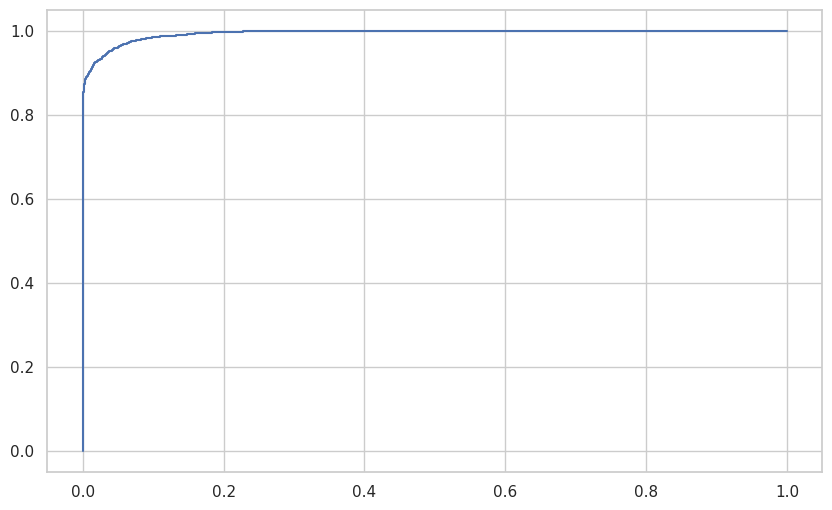

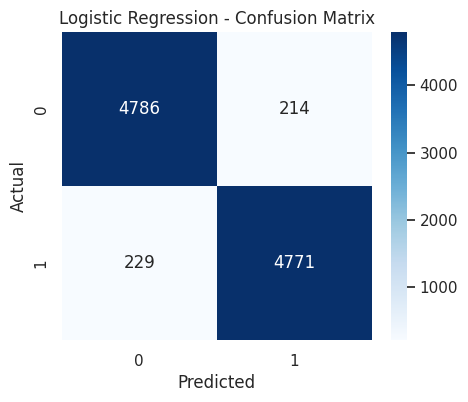

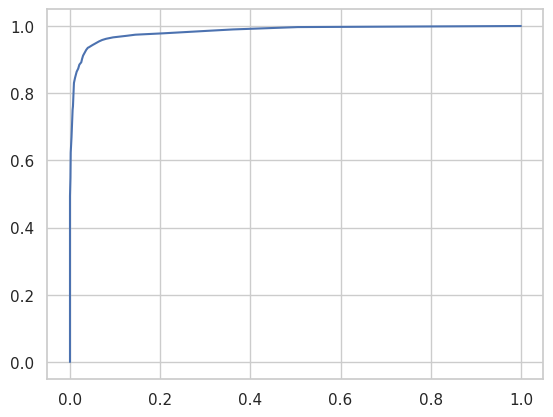

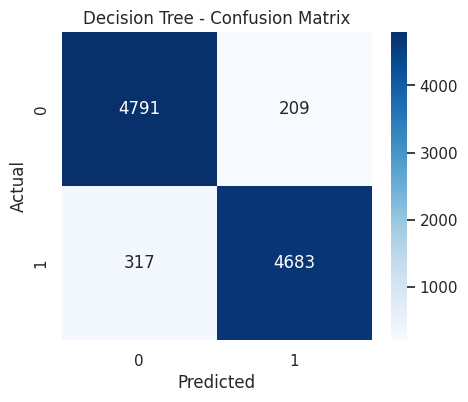

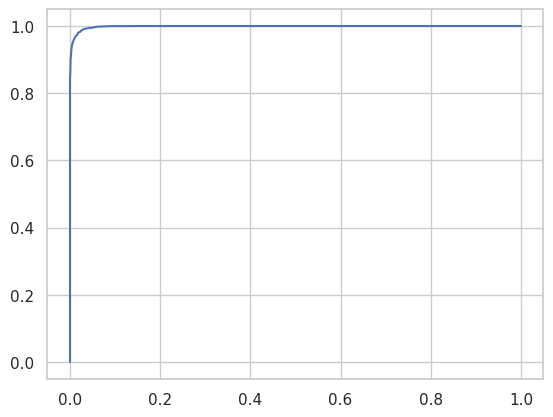

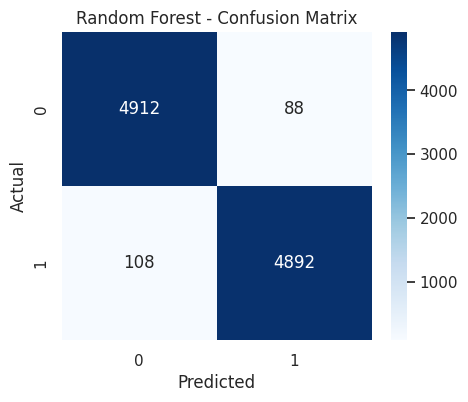

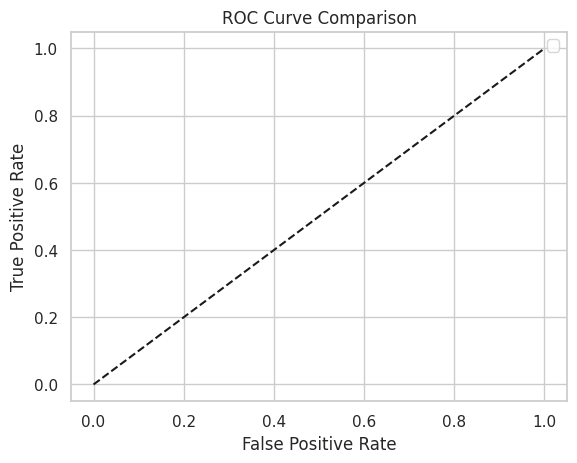


=== Model Performance ===
                     Accuracy  Precision  Recall  F1 Score   ROC AUC
Logistic Regression    0.9557   0.957071  0.9542  0.955633  0.994128
Decision Tree          0.9474   0.957277  0.9366  0.946826  0.984212
Random Forest          0.9804   0.982329  0.9784  0.980361  0.998703

Best Model based on ROC AUC: Random Forest


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score
)

# ================================
# 3. Target Creation
# Convert Viral_Potential_Index → Binary
# ================================
threshold = df['Viral_Potential_Index'].median()

df['Target'] = (df['Viral_Potential_Index'] > threshold).astype(int)

# ================================
# 4. Features & Target Split
# ================================
X = df.drop(columns=['Viral_Potential_Index', 'Target'])
y = df['Target']

# ================================
# 5. Train-Test Split (NO LEAKAGE)
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ================================
# 6. Feature Scaling (ONLY TRAIN FIT)
# ================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================================
# 7. Models
# ================================
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

# ================================
# 8. Training & Evaluation
# ================================
results = {}

plt.figure(figsize=(10, 6))

for name, model in models.items():

    # Train
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = [acc, prec, rec, f1, auc]

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ================================
# 9. ROC Curve Plot
# ================================
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ================================
# 10. Results Table
# ================================
results_df = pd.DataFrame(results).T
results_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

print("\n=== Model Performance ===")
print(results_df)

# ================================
# 11. Best Model
# ================================
best_model = results_df['ROC AUC'].idxmax()
print(f"\nBest Model based on ROC AUC: {best_model}")

## Thank you..pls upvote!!!!!!!!